![Henry Logo](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)



# M3L1 E00 - Pipeline Mock vs Agente ReAct
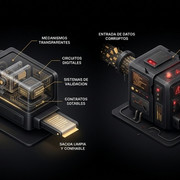

*Figura E00. Pipeline tradicional vs agente ReAct con DolarAPI.*

## Importante antes de empezar

Este notebook **no usa una API real de IA**.

La respuesta del supuesto LLM esta simulada con `llm_pipeline_mock()` para que la practica se enfoque en arquitectura.

La tool de datos, en cambio, **si consulta una API real**: DolarAPI.

Entonces, aca no estamos validando si una IA responde bien. Estamos validando esta diferencia:

> Pipeline: responde sin consultar datos actuales.  
> Agente: usa una tool real, observa el resultado y responde con ese dato.

## Objetivo del ejercicio

Completar un agente ReAct minimo que responda cuanto son 100 USD en pesos argentinos usando una consulta real a DolarAPI.

## Que vamos a mirar con prints

En vez de usar muchos asserts, vamos a imprimir la salida de cada pieza:

- URL de DolarAPI;
- resultado de `obtener_dolar_blue()`;
- resultado de `convertir_usd_a_pesos()`;
- respuesta final de `agente_react()`.

La idea es que el alumno vea paso a paso que devuelve cada funcion.


## Definiciones usadas en este notebook

| Concepto | Definicion simple | Como aparece en este notebook |
|---|---|---|
| LLM Pipeline | Flujo fijo que recibe input y devuelve texto. | `llm_pipeline_mock()` responde sin usar tools. |
| AI Agent | Sistema que puede decidir acciones y observar resultados. | `agente_react()` llama tools antes de responder. |
| Tool | Funcion que obtiene datos o ejecuta una accion. | `obtener_dolar_blue()` y `convertir_usd_a_pesos()`. |
| Observation | Resultado que devuelve una tool. | La cotizacion del dolar y el total convertido. |
| Grounding | Respuesta basada en datos observados. | La respuesta final cita cotizacion, fecha y fuente. |
| Trace | Registro de pasos ejecutados. | Los prints muestran Thought, Action y Observation. |
| ReAct | Reasoning + Acting. | Pensar -> actuar -> observar -> responder. |

En este ejercicio dejamos fuera `state` complejo y `max_steps` para mantener el foco en la diferencia entre pipeline y agente.


## Paso 1 - Pipeline LLM simulado

Ejecuta esta celda. Observa que no aparece ninguna tool ni ninguna observacion externa.


In [ ]:
PREGUNTA = "Cuanto son 100 USD en pesos argentinos hoy?"


def llm_pipeline_mock(pregunta: str) -> str:
    """Simula una respuesta de IA sin tools.

    En una clase real podriamos reemplazar esta funcion por una llamada a una API
    de IA, pero para este ejercicio queremos enfocarnos en arquitectura de agentes.
    """
    print("[Pipeline] Pregunta del usuario:")
    print(f"[Pipeline] {pregunta}")
    print("[Pipeline] Respondo sin consultar datos actuales.")
    return "100 USD son aproximadamente 100.000 pesos argentinos."


respuesta_pipeline = llm_pipeline_mock(PREGUNTA)
print(f"[Respuesta pipeline] {respuesta_pipeline}")
print("[Problema] Esta respuesta puede estar desactualizada porque no uso una tool.")


## Paso 2 - API real de cotizacion

Vamos a usar DolarAPI:

```text
https://dolarapi.com/v1/dolares/blue
```

La API devuelve un JSON con datos como:

```python
{
    "compra": 1000,
    "venta": 1020,
    "fechaActualizacion": "..."
}
```

La tool va a consultar esa URL y devolver un contrato simple para el agente.


In [ ]:
import requests

DOLAR_API_URL = "https://dolarapi.com/v1/dolares/blue"


### Por qu? normalizar el payload de la API

Las APIs externas pueden cambiar su formato en cualquier momento.

Si tu agente depende directamente del formato crudo de la API, un campo renombrado
`compra` -> `precio_compra` puede romper todo el sistema sin aviso.

La solucion es crear un **contrato interno estable**: la tool transforma el payload
externo en una estructura que el agente siempre puede esperar.

```python
# Payload externo (puede cambiar sin aviso)
{"compra": 1000, "venta": 1020, "fechaActualizacion": "..."}

# Contrato interno (estable, controlado por nosotros)
{"compra": float, "venta": float, "fecha": str, "source": str}
```

Este patron es uno de los **7 principios de diseno robusto** descritos en la notebook.


## Paso 3 - TODO 1: completar la tool de cotizacion

La tool debe transformar el payload externo en un contrato interno estable.


In [ ]:
def obtener_dolar_blue() -> dict:
    """Tool: consulta DolarAPI y normaliza la cotizacion del dolar blue."""
    response = requests.get(DOLAR_API_URL, timeout=10)
    response.raise_for_status()
    payload = response.json()
    print(f"payload DolarAPI -> {payload}")

    # TODO 1: devolver un diccionario normalizado con estas claves:
    # compra -> float(payload["compra"])
    # venta -> float(payload["venta"])
    # fecha -> payload["fechaActualizacion"]
    # source -> "DolarAPI"
    pass


### Por qu? delegar el c?lculo a una tool

Los modelos de lenguaje pueden equivocarse en operaciones numericas.

La notebook describe las **tools de calculo** como herramientas para tareas deterministicas:

> "Sirven para calculos deterministicos donde no queremos depender del razonamiento
> aproximado del LLM."

Al mover el calculo `monto * cotizacion` a una funcion Python:

- el resultado siempre es preciso,
- se puede testear de forma aislada,
- el agente no necesita razonar sobre aritmetica.

La validacion `> 0` previene resultados absurdos (cotizacion negativa, monto cero).


## Paso 4 - TODO 2: completar la tool de calculo

Esta tool valida inputs y hace un calculo deterministico.


In [ ]:
def convertir_usd_a_pesos(monto_usd: float, cotizacion: float) -> float:
    """Tool: convierte USD a pesos usando una cotizacion."""
    # TODO 2: validar que monto_usd y cotizacion sean mayores a 0.
    # Luego devolver round(monto_usd * cotizacion, 2).
    pass


## Paso 5 - Debug visual de tools

Ejecuta esta celda despues de completar las dos tools.

No usamos asserts aca. Usamos prints para ver claramente:

1. que URL vamos a consultar;
2. que devuelve `obtener_dolar_blue()`;
3. que valor de venta toma el agente;
4. que devuelve `convertir_usd_a_pesos()`.

Si algo sale `None` o rompe, el problema esta en la tool que acabas de completar.


In [ ]:
print(f"DOLAR_API_URL = {DOLAR_API_URL}")

cotizacion_demo = obtener_dolar_blue()
print(f"obtener_dolar_blue() -> {cotizacion_demo}")

venta_demo = cotizacion_demo["venta"]
print(f"cotizacion_demo['venta'] -> {venta_demo}")

conversion_demo = convertir_usd_a_pesos(100, venta_demo)
print(f"convertir_usd_a_pesos(100, {venta_demo}) -> {conversion_demo}")


### El patr?n ReAct en este agente

ReAct significa **Reasoning + Acting**. El agente alterna entre pensar y actuar:

```text
Thought -> Action -> Observation -> Thought -> Action -> Observation -> Final Answer
```

En este ejercicio:

```text
[Thought]     Necesito la cotizacion actual.
[Action]      obtener_dolar_blue()
[Observation] {compra: ..., venta: ..., fecha: ...}

[Thought]     Uso la venta para convertir 100 USD.
[Action]      convertir_usd_a_pesos(100, venta)
[Observation] total_pesos

[Final Answer] 100 USD son {total_pesos} pesos al tipo de cambio de hoy.
```

La respuesta final es **grounded** porque incluye la cotizacion, la fecha y la fuente.
No es una estimacion: es un dato verificable.


## Paso 6 - TODO 3: completar el agente ReAct

El agente debe seguir: Thought -> Action -> Observation -> Thought -> Action -> Observation -> Final Answer.


In [ ]:
def agente_react(pregunta: str) -> str:
    print("[Agente] Pregunta del usuario:")
    print(f"[Agente] {pregunta}")

    print("[Thought] Necesito una cotizacion antes de responder.")
    print("[Action] obtener_dolar_blue()")

    # TODO 3.1: llamar la tool obtener_dolar_blue().
    # cotizacion = ...

    # TODO 3.2: imprimir la observacion.
    # print(f"[Observation] {cotizacion}")

    print("[Thought] Uso la cotizacion de venta para convertir 100 USD.")
    print("[Action] convertir_usd_a_pesos(100, venta)")

    # TODO 3.3: tomar venta y calcular total_pesos.
    # venta = ...
    # total_pesos = ...

    # TODO 3.4: devolver la respuesta final grounded.
    pass


## Paso 7 - Debug final del agente

Ejecuta el agente completo.

Lo importante es mirar el trace:

- pregunta del usuario;
- Thought;
- Action;
- Observation;
- respuesta final.

Si la respuesta final sale `None`, falta el `return` del TODO 3.4.


In [ ]:
respuesta_agente = agente_react(PREGUNTA)
print(f"agente_react(PREGUNTA) -> {respuesta_agente}")


## Cierre - Que deberia quedar claro

Este ejercicio no busca mostrar una API de IA.

Busca mostrar esta diferencia:

| Pipeline mock | Agente ReAct |
|---|---|
| Responde texto directo. | Usa una tool real antes de responder. |
| No observa datos actuales. | Observa la cotizacion desde DolarAPI. |
| No tiene grounding. | Incluye fecha y fuente. |
| No deja trace de acciones. | Muestra Thought, Action y Observation. |

Cuando quieras conectar esto con una API real de IA, `llm_pipeline_mock()` podria reemplazarse por una llamada a OpenAI, Gemini, Claude, etc.

Pero el patron que estamos aprendiendo no depende de eso: depende de tools, observaciones y respuesta grounded.
